# Datathon - Passos Mágicos
Neste notebook vamos analisar os dados da pesquisa PEDE - 2024, para realizar uma análise exploratória de dados e responder ao seguinte questionário proposto:

1.   **Adequação do nível (IAN)**: Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?
2.   **Desempenho acadêmico (IDA)**: O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?
3.   **Engajamento nas atividades (IEG)**: O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?
4.   **Autoavaliação (IAA)**: As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?
5.   **Aspectos psicossociais (IPS)**: Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?
6.   **Aspectos psicopedagógicos (IPP)**: As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?
7.   **Ponto de virada (IPV)**: Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?
8.   **Multidimensionalidade dos indicadores**: Quais combinações de indicadores (IDA + IEG + IPS + IPP) melhor explicam o desempenho global do aluno (INDE)?
9.   **Previsão de risco com Machine Learning**: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.
10.   **Efetividade do programa**: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

## Análise Exploratória de Dados

In [3]:
import pandas as pd
import numpy as np

## Tratamento de Dados
Nessa etapa realizaremos os seguintes tratamentos nos datasets:
1.   **Remoção das colunas com valores nulos**: remover um conjunto de colunas com dados nulos em todas as linhas
2.   **Tratamento da coluna RA**: Aplicar o tratamento de remoção dos prefixos `RA-` para manter somente os dados numéricos que servirá como identificador único de cada aluno
3.   **Converter string para float**: Alterar o separador de decimal de `,` para `.` e alterar o formato de `object` para `float64`

### Funções

In [4]:
def remover_colunas_vazias(df):
  df.dropna(axis=1, how='all', inplace=True)

def remover_prefixo_RA(df):
  df['RA'] = df['RA'].str.lstrip('RA-').astype(int)

def converter_colunas_para_float(df, colunas_float):
  for coluna in colunas_float:

      if coluna in df.columns:
          df[coluna] = df[coluna].astype(str).str.replace(',', '.', regex=False)
          df[coluna] = pd.to_numeric(df[coluna], errors='coerce').fillna(0).astype('float64')

def remover_colunas(df, colunas_para_remover):
  colunas = [col for col in colunas_para_remover if col in df.columns]
  df.drop(columns=colunas, inplace=True)

def renomear_colunas(df, colunas_para_renomear):
  df.rename(columns=colunas_para_renomear, inplace=True)

def adicionar_sufixo_ano(df, ano):
  sufixo = f'_{ano}'
  colunas_para_modificar = df.columns[1:]
  df.rename(columns={col: col + sufixo for col in colunas_para_modificar}, inplace=True)

def transformar_booleano(df, colunas_booleano, dict_booleano):
  for coluna in colunas_booleano:
    df[coluna] = df[coluna].map(dict_booleano)

def calcular_ipp(df, col_fase):
    df['IPP'] = np.where(
        df[col_fase] <= 7,
        (df['INDE 22'] - (df['IAN']  * 0.1) - (df['IDA']  * 0.2) - (df['IEG']  * 0.2) - (df['IAA']  * 0.1) - (df['IPS']  * 0.1) - (df['IPV']  * 0.2)) / 0.1,
        0
    )
    return df


### Dados PEDE 2024

In [5]:
ano = '2024'
url = 'https://raw.githubusercontent.com/denis-hwk/datathon_postech_fiap_9dtat_grupo140/refs/heads/main/dataset/Datathon_PEDE_2024.csv'
dados_2024 = pd.read_csv(url, parse_dates=['Data de Nasc'], date_format='%d/%m/%Y')

dados_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1155 non-null   object        
 3   Pedra 2024             1155 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

In [6]:
remover_colunas_vazias(dados_2024)
remover_prefixo_RA(dados_2024)

In [7]:
colunas_remover = [
    'Nome Anonimizado', 'Destaque IPV.1', 'Data de Nasc', 'Ativo/ Inativo', 'Ativo/ Inativo.1',
    'Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4', 'Avaliador5', 'Avaliador6',
    'Rec Av4', 'Nº Av', 'Pedra 20', 'Pedra 21','Pedra 23', 'Pedra 22', 'INDE 23',
    'INDE 22'
    ]

remover_colunas(dados_2024, colunas_remover)

In [8]:
colunas_float = [
    'INDE 2024', 'INDE 23', 'INDE 22', 'IAA', 'IEG',
    'IPS', 'IPP', 'IDA', 'Mat', 'Por',
    'Ing', 'IPV', 'IAN'
    ]

converter_colunas_para_float(dados_2024, colunas_float)

In [9]:
colunas_para_renomear={
    'INDE 2024': 'INDE',
    'Pedra 2024': 'Pedra',
    'Gênero': 'Genero',
    'Ano ingresso': 'Ano_Ingresso',
    'Fase Ideal': 'Fase_Ideal',
    'Defasagem': 'Defasagem',
    'Instituição de ensino': 'Instituicao_Ensino'
    }

renomear_colunas(dados_2024, colunas_para_renomear)

In [10]:
adicionar_sufixo_ano(dados_2024, ano)

In [11]:
dados_2024.head()

,RA,Fase_2024,INDE_2024,Pedra_2024,Turma_2024,Idade_2024,Genero_2024,Ano_Ingresso_2024,Instituicao_Ensino_2024,IAA_2024,...,IPP_2024,IDA_2024,Mat_2024,Por_2024,Ing_2024,IPV_2024,IAN_2024,Fase_Ideal_2024,Defasagem_2024,Escola_2024
0,1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,8,Masculino,2024,Pública,10.0,...,5.6,8.0,10.0,6.0,0.0,5.4,10.0,ALFA (1° e 2° ano),0,EE Chácara Florida II
1,1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,8,Feminino,2024,Pública,10.0,...,7.5,8.0,10.0,6.0,0.0,7.1,10.0,ALFA (1° e 2° ano),0,EE Chácara Florida II
2,1277,ALFA,7.952200,Ametista,ALFA A - G0/G1,8,Masculino,2024,Pública,10.0,...,7.5,8.0,10.0,6.0,0.0,7.0,10.0,ALFA (1° e 2° ano),0,EE Dom Pedro Villas Boas de Souza
3,868,ALFA,7.156367,Ametista,ALFA A - G0/G1,8,Masculino,2023,Pública,8.0,...,6.9,7.0,8.0,6.0,0.0,7.2,5.0,Fase 1 (3° e 4° ano),-1,EE Chácara Florida II
4,1278,ALFA,5.444200,Quartzo,ALFA A - G0/G1,9,Masculino,2024,Pública,9.0,...,5.0,7.5,8.0,7.0,0.0,4.2,5.0,Fase 1 (3° e 4° ano),-1,EM Etelvina Delfim Simões


In [12]:
dados_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RA                       1156 non-null   int64  
 1   Fase_2024                1156 non-null   object 
 2   INDE_2024                1156 non-null   float64
 3   Pedra_2024               1155 non-null   object 
 4   Turma_2024               1156 non-null   object 
 5   Idade_2024               1156 non-null   int64  
 6   Genero_2024              1156 non-null   object 
 7   Ano_Ingresso_2024        1156 non-null   int64  
 8   Instituicao_Ensino_2024  1155 non-null   object 
 9   IAA_2024                 1156 non-null   float64
 10  IEG_2024                 1156 non-null   float64
 11  IPS_2024                 1156 non-null   float64
 12  IPP_2024                 1156 non-null   float64
 13  IDA_2024                 1156 non-null   float64
 14  Mat_2024                

### Dados PEDE 2023

In [13]:
ano = '2023'
url = 'https://raw.githubusercontent.com/denis-hwk/datathon_postech_fiap_9dtat_grupo140/refs/heads/main/dataset/Datathon_PEDE_2023.csv'
dados_2023 = pd.read_csv(url, parse_dates=['Data de Nasc'], date_format='%m/%d/%Y')

In [14]:
dados_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1014 non-null   object        
 1   Fase                   1014 non-null   object        
 2   INDE 2023              932 non-null    object        
 3   Pedra 2023             932 non-null    object        
 4   Turma                  1014 non-null   object        
 5   Nome Anonimizado       1014 non-null   object        
 6   Data de Nasc           1014 non-null   datetime64[ns]
 7   Idade                  1014 non-null   int64         
 8   Gênero                 1014 non-null   object        
 9   Ano ingresso           1014 non-null   int64         
 10  Instituição de ensino  1014 non-null   object        
 11  Pedra 20               240 non-null    object        
 12  Pedra 21               335 non-null    object        
 13  Ped

In [15]:
remover_colunas_vazias(dados_2023)
remover_prefixo_RA(dados_2023)

In [16]:
colunas_float = [
    'INDE 2023', 'INDE 22', 'IAA', 'IEG',
    'IPS', 'IPP', 'IDA', 'Mat', 'Por', 'Ing',
    'IPV', 'IAN'
    ]

converter_colunas_para_float(dados_2023, colunas_float)

In [17]:
colunas_remover = [
    'Nome Anonimizado', 'Data de Nasc',
    'Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4', 'Nº Av',
    'INDE 22', 'Pedra 20', 'Pedra 21', 'Pedra 22'
    ]

remover_colunas(dados_2023, colunas_remover)

In [18]:
colunas_para_renomear={
    'INDE 2023': 'INDE',
    'Pedra 2023': 'Pedra',
    'Gênero': 'Genero',
    'Ano ingresso': 'Ano_Ingresso',
    'Fase Ideal': 'Fase_Ideal',
    'Instituição de ensino': 'Instituicao_Ensino'
    }
renomear_colunas(dados_2023, colunas_para_renomear)

In [19]:
adicionar_sufixo_ano(dados_2023, ano)

In [20]:
dados_2023.head()

,RA,Fase_2023,INDE_2023,Pedra_2023,Turma_2023,Idade_2023,Genero_2023,Ano_Ingresso_2023,Instituicao_Ensino_2023,IAA_2023,...,IPS_2023,IPP_2023,IDA_2023,Mat_2023,Por_2023,Ing_2023,IPV_2023,IAN_2023,Fase_Ideal_2023,Defasagem_2023
0,861,ALFA,9.31095,Topázio,ALFA A - G0/G1,8,Feminino,2023,Pública,9.5,...,8.13,8.4375,9.6,9.8,9.4,0.0,8.920,10.0,ALFA (1° e 2° ano),0
1,862,ALFA,8.22120,Topázio,ALFA A - G0/G1,9,Masculino,2023,Pública,8.5,...,8.14,7.5000,8.9,8.5,9.2,0.0,8.585,5.0,Fase 1 (3° e 4° ano),-1
2,863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,7,Masculino,2023,Pública,0.0,...,3.14,5.9375,6.3,7.0,5.5,0.0,6.260,10.0,ALFA (1° e 2° ano),0
3,864,ALFA,7.03400,Ametista,ALFA A - G0/G1,8,Feminino,2023,Pública,0.0,...,8.14,7.5000,6.3,7.0,5.5,0.0,8.500,10.0,ALFA (1° e 2° ano),0
4,865,ALFA,8.15520,Topázio,ALFA A - G0/G1,8,Masculino,2023,Pública,8.5,...,7.52,7.5000,7.4,7.3,7.5,0.0,7.915,10.0,ALFA (1° e 2° ano),0


In [21]:
dados_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RA                       1014 non-null   int64  
 1   Fase_2023                1014 non-null   object 
 2   INDE_2023                1014 non-null   float64
 3   Pedra_2023               932 non-null    object 
 4   Turma_2023               1014 non-null   object 
 5   Idade_2023               1014 non-null   int64  
 6   Genero_2023              1014 non-null   object 
 7   Ano_Ingresso_2023        1014 non-null   int64  
 8   Instituicao_Ensino_2023  1014 non-null   object 
 9   IAA_2023                 1014 non-null   float64
 10  IEG_2023                 1014 non-null   float64
 11  IPS_2023                 1014 non-null   float64
 12  IPP_2023                 1014 non-null   float64
 13  IDA_2023                 1014 non-null   float64
 14  Mat_2023                

### Dados PEDE 2022

In [22]:
ano = '2022'
url = 'https://raw.githubusercontent.com/denis-hwk/datathon_postech_fiap_9dtat_grupo140/refs/heads/main/dataset/Datathon_PEDE_2022.csv'
dados_2022 = pd.read_csv(url)
dados_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   RA                     860 non-null    object
 1   Fase                   860 non-null    int64 
 2   Turma                  860 non-null    object
 3   Nome                   860 non-null    object
 4   Ano nasc               860 non-null    int64 
 5   Idade 22               860 non-null    int64 
 6   Gênero                 860 non-null    object
 7   Ano ingresso           860 non-null    int64 
 8   Instituição de ensino  860 non-null    object
 9   Pedra 20               323 non-null    object
 10  Pedra 21               462 non-null    object
 11  Pedra 22               860 non-null    object
 12  INDE 22                860 non-null    object
 13  Cg                     860 non-null    object
 14  Cf                     860 non-null    int64 
 15  Ct                     

In [23]:
remover_colunas_vazias(dados_2022)
remover_prefixo_RA(dados_2022)

In [24]:
colunas_float = [
    'INDE 22', 'IAA', 'IEG','IPS', 'IPP', 'IDA',
    'Matem', 'Portug', 'Inglês', 'IPV', 'IAN', 'Cg'
    ]

converter_colunas_para_float(dados_2022, colunas_float)

In [25]:
calcular_ipp(dados_2022, 'Fase')

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,IPP
0,1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.174
1,2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,7.894
2,3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,8.198
3,4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,5.554
4,5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,0,Z,Aluno-856,2015,7,Menino,2022,Escola Pública,NaN,...,Não,Não,8.000,10.0,ALFA (2º e 3º ano),0,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios ...,5.480
856,857,0,Z,Aluno-857,2013,9,Menina,2022,Escola Pública,NaN,...,Não,Sim,9.083,5.0,Fase 1 (4º ano),-1,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios ...,5.574
857,858,0,Z,Aluno-858,2015,7,Menino,2022,Escola Pública,NaN,...,Não,Não,7.333,10.0,ALFA (2º e 3º ano),0,Melhorar: Melhorar a sua entrega de lições de ...,Destaque: As suas boas notas na Passos Mágicos.,Melhorar: Integrar-se mais aos Princípios Pass...,5.364
858,859,0,Z,Aluno-859,2015,7,Menina,2022,Escola Pública,NaN,...,Não,Não,8.250,10.0,ALFA (2º e 3º ano),0,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios ...,5.550


In [26]:
colunas_remover = [
    'Nome', 'Ano nasc', 'Pedra 20', 'Pedra 21',
    'Avaliador1', 'Avaliador2', 'Avaliador3', 'Avaliador4', 'Rec Av3',
    'Rec Av4', 'Nº Av']

remover_colunas(dados_2022, colunas_remover)

In [27]:
colunas_para_renomear = {
    'Idade 22': 'Idade',
    'INDE 22': 'INDE',
    'Gênero': 'Genero',
    'Ano ingresso': 'Ano_Ingresso',
    'Instituição de ensino': 'Instituicao_Ensino',
    'Pedra 22': 'Pedra',
    'Rec Av1': 'Rec_Av1',
    'Rec Av2': 'Rec_Av2',
    'Rec Psicologia': 'Rec_Psicologia',
    'Matem': 'Mat',
    'Portug': 'Por',
    'Inglês': 'Ing',
    'Atingiu PV': 'Atingiu_PV',
    'Fase ideal': 'Fase_Ideal',
    'Defas': 'Defasagem',
    'Destaque IEG': 'Destaque_IEG',
    'Destaque IDA': 'Destaque_IDA',
    'Destaque IPV': 'Destaque_IPV'
    }

renomear_colunas(dados_2022, colunas_para_renomear)

In [28]:
adicionar_sufixo_ano(dados_2022, ano)

In [29]:
dados_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RA                       860 non-null    int64  
 1   Fase_2022                860 non-null    int64  
 2   Turma_2022               860 non-null    object 
 3   Idade_2022               860 non-null    int64  
 4   Genero_2022              860 non-null    object 
 5   Ano_Ingresso_2022        860 non-null    int64  
 6   Instituicao_Ensino_2022  860 non-null    object 
 7   Pedra_2022               860 non-null    object 
 8   INDE_2022                860 non-null    float64
 9   Cg_2022                  860 non-null    float64
 10  Cf_2022                  860 non-null    int64  
 11  Ct_2022                  860 non-null    int64  
 12  Rec_Av1_2022             860 non-null    object 
 13  Rec_Av2_2022             860 non-null    object 
 14  IAA_2022                 8

In [30]:
dados_2022.head()

,RA,Fase_2022,Turma_2022,Idade_2022,Genero_2022,Ano_Ingresso_2022,Instituicao_Ensino_2022,Pedra_2022,INDE_2022,Cg_2022,...,Indicado_2022,Atingiu_PV_2022,IPV_2022,IAN_2022,Fase_Ideal_2022,Defasagem_2022,Destaque_IEG_2022,Destaque_IDA_2022,Destaque_IPV_2022,IPP_2022
0,1,7,A,19,Menina,2016,Escola Pública,Quartzo,5.783,753.0,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.174
1,2,7,A,17,Menina,2017,Rede Decisão,Ametista,7.055,469.0,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,7.894
2,3,7,A,17,Menina,2016,Rede Decisão,Ágata,6.591,629.0,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,8.198
3,4,7,A,17,Menino,2017,Rede Decisão,Quartzo,5.951,731.0,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,5.554
4,5,7,A,17,Menina,2016,Rede Decisão,Ametista,7.427,344.0,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.392


### Consolidação dos Dados

In [31]:
df_final = dados_2024.merge(dados_2023, on = 'RA', how='left').merge(dados_2022, on='RA', how='left')

In [32]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 73 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   RA                       1156 non-null   int64  
 1   Fase_2024                1156 non-null   object 
 2   INDE_2024                1156 non-null   float64
 3   Pedra_2024               1155 non-null   object 
 4   Turma_2024               1156 non-null   object 
 5   Idade_2024               1156 non-null   int64  
 6   Genero_2024              1156 non-null   object 
 7   Ano_Ingresso_2024        1156 non-null   int64  
 8   Instituicao_Ensino_2024  1155 non-null   object 
 9   IAA_2024                 1156 non-null   float64
 10  IEG_2024                 1156 non-null   float64
 11  IPS_2024                 1156 non-null   float64
 12  IPP_2024                 1156 non-null   float64
 13  IDA_2024                 1156 non-null   float64
 14  Mat_2024                

In [33]:
df_final.head()

,RA,Fase_2024,INDE_2024,Pedra_2024,Turma_2024,Idade_2024,Genero_2024,Ano_Ingresso_2024,Instituicao_Ensino_2024,IAA_2024,...,Indicado_2022,Atingiu_PV_2022,IPV_2022,IAN_2022,Fase_Ideal_2022,Defasagem_2022,Destaque_IEG_2022,Destaque_IDA_2022,Destaque_IPV_2022,IPP_2022
0,1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,8,Masculino,2024,Pública,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,8,Feminino,2024,Pública,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1277,ALFA,7.952200,Ametista,ALFA A - G0/G1,8,Masculino,2024,Pública,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,868,ALFA,7.156367,Ametista,ALFA A - G0/G1,8,Masculino,2023,Pública,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1278,ALFA,5.444200,Quartzo,ALFA A - G0/G1,9,Masculino,2024,Pública,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [197]:
df_final.to_csv('df_dashboard.csv', index=False)

In [205]:
df_final['Defasagem_2024'].unique()

array([ 0, -1, -2,  1,  3, -3,  2])

## Visualização dos Dados

In [34]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

### 1. IAN

In [35]:
dados_IAN = df_final[['RA', 'IAN_2022', 'IAN_2023', 'IAN_2024']]
dados_IAN = pd.melt(
    dados_IAN,
    id_vars = ['RA'],
    value_vars = ['IAN_2022', 'IAN_2023', 'IAN_2024'],
    var_name = 'Ano',
    value_name = 'IAN'
    )
dados_IAN['Ano'] = dados_IAN['Ano'].str.replace('IAN_', '')
dados_IAN.dropna(subset=['IAN'], inplace=True)
dados_IAN.head()

,RA,Ano,IAN
50,702,2022,10.0
51,725,2022,10.0
79,858,2022,10.0
84,729,2022,10.0
99,754,2022,5.0


In [193]:
contagem_IAN = dados_IAN.groupby(['Ano','IAN'])['RA'].nunique().reset_index()
contagem_IAN.head()

,Ano,IAN,RA
0,2022,2.5,7
1,2022,5.0,311
2,2022,10.0,154
3,2023,2.5,4
4,2023,5.0,391


In [195]:
fig = px.bar(
    contagem_IAN,
    x='Ano',
    y='RA',
    color='IAN',
    barmode='stack'
    )
fig.update_traces(
    hovertemplate='IAN: %{y:.1f}<extra></extra>'
    )
fig.update_layout(
    barnorm="percent",
    yaxis=dict(title='Percentual'
    )
)
fig.show()

### 2. IDA

In [38]:
dados_IDA = df_final[['RA', 'IDA_2022', 'IDA_2023', 'IDA_2024']]
dados_IDA = pd.melt(
    dados_IDA,
    id_vars = ['RA'],
    value_vars = ['IDA_2022', 'IDA_2023', 'IDA_2024'],
    var_name = 'Ano',
    value_name = 'IDA'
    )
dados_IDA['Ano'] = dados_IDA['Ano'].str.replace('IDA_', '')
dados_IDA.dropna(subset=['IDA'], inplace=True)
dados_IDA.head()

,RA,Ano,IDA
50,702,2022,6.8
51,725,2022,5.0
79,858,2022,7.7
84,729,2022,8.1
99,754,2022,7.9


In [39]:
fig = px.histogram(
    dados_IDA,
    x='IDA',
    y='RA',
    color='Ano',
    barmode='group',
    histnorm='percent',
    histfunc='count',
    nbins=20
    )
fig.show()

### 3. IEG

In [40]:
dados_IEG = df_final[['RA', 'IEG_2022', 'IEG_2023', 'IEG_2024']]
dados_IEG = pd.melt(
    dados_IEG,
    id_vars = ['RA'],
    value_vars = ['IEG_2022', 'IEG_2023', 'IEG_2024'],
    var_name = 'Ano',
    value_name = 'IEG'
    )
dados_IEG['Ano'] = dados_IEG['Ano'].str.replace('IEG_', '')
dados_IEG.head()

,RA,Ano,IEG
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [41]:
dados_IPV = df_final[['RA', 'IPV_2022', 'IPV_2023', 'IPV_2024']]
dados_IPV = pd.melt(
    dados_IPV,
    id_vars = ['RA'],
    value_vars = ['IPV_2022', 'IPV_2023', 'IPV_2024'],
    var_name = 'Ano',
    value_name = 'IPV'
    )
dados_IPV['Ano'] = dados_IPV['Ano'].str.replace('IPV_', '')
dados_IPV.head()

,RA,Ano,IPV
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [42]:
dados_IEG_IDA = dados_IEG.merge(dados_IDA, on=['RA', 'Ano'], how='left')
dados_eng_desempenho = dados_IEG_IDA.merge(dados_IPV, on=['RA', 'Ano'], how='left')
dados_eng_desempenho.head()

,RA,Ano,IEG,IDA,IPV
0,1275,2022,NaN,NaN,NaN
1,1276,2022,NaN,NaN,NaN
2,1277,2022,NaN,NaN,NaN
3,868,2022,NaN,NaN,NaN
4,1278,2022,NaN,NaN,NaN


In [43]:
matriz_correlacao_engajamento = dados_eng_desempenho[['IEG','IDA','IPV']].corr()
fig = px.imshow(
    matriz_correlacao_engajamento,
    text_auto=True)
fig.show()

In [44]:
fig = px.scatter(
    dados_eng_desempenho,
    x='IEG',
    y='IPV',
    trendline='ols'
)
fig.show()

In [45]:
fig = px.scatter(
    dados_eng_desempenho,
    x='IEG',
    y='IDA',
    trendline='ols'
)
fig.show()

### 4. IAA

In [46]:
dados_IAA = df_final[['RA', 'IAA_2022', 'IAA_2023', 'IAA_2024']]
dados_IAA = pd.melt(
    dados_IAA,
    id_vars = ['RA'],
    value_vars = ['IAA_2022', 'IAA_2023', 'IAA_2024'],
    var_name = 'Ano',
    value_name = 'IAA'
    )
dados_IAA['Ano'] = dados_IAA['Ano'].str.replace('IAA_', '')
dados_IAA.head()

,RA,Ano,IAA
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [47]:
dados_IAA_IDA = dados_IAA.merge(dados_IDA, on=['RA', 'Ano'], how='left')
dados_autoavaliacao = dados_IAA_IDA.merge(dados_IEG, on=['RA', 'Ano'], how='left')
dados_autoavaliacao.dropna(subset=['IAA', 'IDA', 'IEG'], inplace=True)
dados_autoavaliacao.head()

,RA,Ano,IAA,IDA,IEG
50,702,2022,10.0,6.8,8.6
51,725,2022,8.0,5.0,5.9
79,858,2022,10.0,7.7,7.1
84,729,2022,10.0,8.1,8.7
99,754,2022,10.0,7.9,5.8


In [48]:
matriz_correlacao_autoavaliacao = dados_autoavaliacao[['IAA','IDA','IEG']].corr()
fig = px.imshow(
    matriz_correlacao_autoavaliacao,
    text_auto=True
    )
fig.show()

In [49]:
fig = px.scatter(
    dados_autoavaliacao,
    x='IAA',
    y='IDA',
    trendline='ols'
)
fig.show()

In [50]:
fig = px.scatter(
    dados_autoavaliacao,
    x='IAA',
    y='IEG',
    trendline='ols'
)
fig.show()

### 5. IPS

In [51]:
dados_IPS = df_final[['RA', 'IPS_2022', 'IPS_2023', 'IPS_2024']]
dados_IPS = pd.melt(
    dados_IPS,
    id_vars = ['RA'],
    value_vars = ['IPS_2022', 'IPS_2023', 'IPS_2024'],
    var_name = 'Ano',
    value_name = 'IPS'
    )
dados_IPS['Ano'] = dados_IPS['Ano'].str.replace('IPS_', '')
dados_IPS.head()

,RA,Ano,IPS
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [52]:
dados_IEG_IDA = dados_IEG.merge(dados_IDA, on=['RA', 'Ano'], how='left')
dados_desempenho = dados_IEG_IDA.merge(dados_IPS, on=['RA', 'Ano'], how='left')
dados_desempenho.head()

,RA,Ano,IEG,IDA,IPS
0,1275,2022,NaN,NaN,NaN
1,1276,2022,NaN,NaN,NaN
2,1277,2022,NaN,NaN,NaN
3,868,2022,NaN,NaN,NaN
4,1278,2022,NaN,NaN,NaN


In [53]:
fig = px.histogram(
    dados_desempenho,
    x='IPS',
    y='RA',
    color='Ano',
    histfunc='count',
    histnorm='percent',
    barmode='group',
    nbins=20)


buttons = [
    dict(
        label="Todos",
        method="update",
        args=[{"visible": [True, True, True]}, {"title": "IPS - 2022 a 2024"}]
    ),
    dict(
        label="2022",
        method="update",
        args=[{"visible": [True, False, False]}, {"title": "IPS - 2022"}]
    ),
    dict(
        label="2023",
        method="update",
        args=[{"visible": [False, True, False]}, {"title": "IPS - 2023"}]
    ),
    dict(
        label="2024",
        method="update",
        args=[{"visible": [False, False, True]}, {"title": "IPS - 2024"}]
    )
]

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, showactive=True)]
)

fig.show()

In [54]:
dados_ips_desempenho = dados_IPS.dropna(subset=['IPS'])
fig = px.box(
    dados_ips_desempenho,
    x='IPS',
    color='Ano')

fig.show()

In [104]:
fig = px.histogram(
    dados_desempenho,
    x='IEG',
    y='RA',
    color='Ano',
    histfunc='count',
    histnorm='percent',
    barmode='group',
    nbins=20)

buttons = [
    dict(
        label="Todos",
        method="update",
        args=[{"visible": [True, True, True]}, {"title": "Todos os dados"}]
    ),
    dict(
        label="2022",
        method="update",
        args=[{"visible": [True, False, False]}, {"title": "2022"}]
    ),
    dict(
        label="2023",
        method="update",
        args=[{"visible": [False, True, False]}, {"title": "2023"}]
    ),
    dict(
        label="2024",
        method="update",
        args=[{"visible": [False, False, True]}, {"title": "2024"}]
    )
]

# 3. Adicionar os botões ao layout
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, showactive=True)]
)
fig.show()

In [56]:
dados_ieg_desempenho = dados_IEG.dropna(subset=['IEG'])
fig = px.box(
    dados_ieg_desempenho,
    x='IEG',
    color='Ano')

fig.show()

In [103]:
fig = px.histogram(
    dados_desempenho,
    x='IDA',
    y='RA',
    color='Ano',
    histfunc='count',
    histnorm='percent',
    barmode='group',
    nbins=20)

buttons = [
    dict(
        label="Todos",
        method="update",
        args=[{"visible": [True, True, True]}, {"title": "IDA - 2022 a 2024"}]
    ),
    dict(
        label="2022",
        method="update",
        args=[{"visible": [True, False, False]}, {"title": "IDA - 2022"}]
    ),
    dict(
        label="2023",
        method="update",
        args=[{"visible": [False, True, False]}, {"title": "IDA - 2023"}]
    ),
    dict(
        label="2024",
        method="update",
        args=[{"visible": [False, False, True]}, {"title": "IDA - 2024"}]
    )
]

# 3. Adicionar os botões ao layout
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, showactive=True)]
)
fig.show()

In [58]:
dados_ida_desempenho = dados_IDA.dropna(subset=['IDA'])
fig = px.box(
    dados_ida_desempenho,
    x='IDA',
    color='Ano'
    )

fig.show()

In [59]:
media_ips_anual = dados_ips_desempenho.groupby('Ano')['IPS'].mean().reset_index()
media_ips_anual.head()

,Ano,IPS
0,2022,6.921398
1,2023,4.667830
2,2024,6.227249


In [60]:
media_ieg_anual = dados_ieg_desempenho.groupby('Ano')['IEG'].mean().reset_index()
media_ieg_anual.head()

,Ano,IEG
0,2022,8.466102
1,2023,8.030458
2,2024,7.374654


In [61]:
media_ida_anual = dados_ida_desempenho.groupby('Ano')['IDA'].mean().reset_index()
media_ida_anual.head()

,Ano,IDA
0,2022,6.652331
1,2023,6.183268
2,2024,5.808564


In [62]:
media_desempenho_anual = media_ips_anual.merge(media_ieg_anual, on='Ano', how='left').merge(media_ida_anual, on='Ano', how='left')
media_desempenho_anual.head()

,Ano,IPS,IEG,IDA
0,2022,6.921398,8.466102,6.652331
1,2023,4.667830,8.030458,6.183268
2,2024,6.227249,7.374654,5.808564


In [102]:
fig = px.bar(
    media_desempenho_anual,
    x='Ano',
    y=['IPS', 'IEG', 'IDA'],
    title='Média de IPS, IEG e IDA por Ano',
    barmode='group'
    )
fig.show()

### 6. IPP

In [64]:
dados_IPP = df_final[['RA', 'IPP_2022', 'IPP_2023', 'IPP_2024']]
dados_IPP = pd.melt(
    dados_IPP,
    id_vars = ['RA'],
    value_vars = ['IPP_2022', 'IPP_2023', 'IPP_2024'],
    var_name = 'Ano',
    value_name = 'IPP'
    )
dados_IPP['Ano'] = dados_IPP['Ano'].str.replace('IPP_', '')
dados_IPP.head()

,RA,Ano,IPP
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [65]:
dados_ipp_defasagem = dados_IPP.merge(dados_IAN, on=['RA', 'Ano'], how='left')
dados_ipp_defasagem.dropna(subset=['IPP', 'IAN'], inplace=True)
dados_ipp_defasagem.head()

,RA,Ano,IPP,IAN
50,702,2022,4.070,10.0
51,725,2022,4.400,10.0
79,858,2022,5.364,10.0
84,729,2022,5.350,10.0
99,754,2022,5.386,5.0


In [105]:
fig_ipp = px.histogram(
    dados_ipp_defasagem,
    x='IPP',
    y='RA',
    color='Ano',
    histfunc='count',
    histnorm='percent',
    barmode='group',
    nbins=20)

fig_ipp.show()

In [67]:
fig_box_ipp = px.box(
    dados_ipp_defasagem,
    x='IPP',
    color='Ano')

fig_box_ipp.show()

In [192]:
dados_ian_contagem = dados_IAN.groupby(['Ano', 'IAN'])['RA'].nunique().reset_index()
fig_ian = px.bar(
    dados_ian_contagem,
    x='Ano',
    y='RA',
    color='IAN',
    barmode='stack'
    )

fig_ian.update_layout(
    barnorm="percent",
    yaxis=dict(title='Percentual'
    )
)

fig_ian.show()

### 7. IPV

In [69]:
dados_IPV = df_final[['RA', 'IPV_2022', 'IPV_2023', 'IPV_2024']]
dados_IPV = pd.melt(
    dados_IPV,
    id_vars = ['RA'],
    value_vars = ['IPV_2022', 'IPV_2023', 'IPV_2024'],
    var_name = 'Ano',
    value_name = 'IPV'
    )
dados_IPV['Ano'] = dados_IPV['Ano'].str.replace('IPV_', '')
dados_IPV.head()

,RA,Ano,IPV
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [70]:
dados_ipv_ida = dados_IPV.merge(dados_IDA, on=['RA', 'Ano'], how='left')
dados_ipv_ieg = dados_ipv_ida.merge(dados_IEG, on=['RA', 'Ano'], how='left')
dados_ipv_ips = dados_ipv_ieg.merge(dados_IPS, on=['RA', 'Ano'], how='left')
dados_ipv_ipp = dados_ipv_ips.merge(dados_IPP, on=['RA', 'Ano'], how='left')
dados_ponto_de_virada = dados_ipv_ipp.merge(dados_IAA, on=['RA', 'Ano'], how='left')
dados_ponto_de_virada.dropna(subset=['IPV', 'IDA', 'IEG', 'IPS', 'IPP'])
dados_ponto_de_virada.head()

,RA,Ano,IPV,IDA,IEG,IPS,IPP,IAA
0,1275,2022,NaN,NaN,NaN,NaN,NaN,NaN
1,1276,2022,NaN,NaN,NaN,NaN,NaN,NaN
2,1277,2022,NaN,NaN,NaN,NaN,NaN,NaN
3,868,2022,NaN,NaN,NaN,NaN,NaN,NaN
4,1278,2022,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
matriz_correlacao_ponto_de_virada = dados_ponto_de_virada[['IPV', 'IDA', 'IEG', 'IPS', 'IPP', 'IAA']].corr()
fig = px.imshow(matriz_correlacao_ponto_de_virada, text_auto=True)
fig.show()

### 8. Multidimensionalidade dos indicadores

In [72]:
dados_INDE = df_final[['RA', 'INDE_2022', 'INDE_2023', 'INDE_2024']]
dados_INDE = pd.melt(
    dados_INDE,
    id_vars = ['RA'],
    value_vars = ['INDE_2022', 'INDE_2023', 'INDE_2024'],
    var_name = 'Ano',
    value_name = 'INDE'
    )
dados_INDE['Ano'] = dados_INDE['Ano'].str.replace('INDE_', '')
dados_INDE.head()

,RA,Ano,INDE
0,1275,2022,NaN
1,1276,2022,NaN
2,1277,2022,NaN
3,868,2022,NaN
4,1278,2022,NaN


In [73]:
dados_INDE_IDA = dados_INDE.merge(dados_IDA, on=['RA', 'Ano'], how='left')
dados_INDE_IEG = dados_INDE_IDA.merge(dados_IEG, on=['RA', 'Ano'], how='left')
dados_INDE_IPP = dados_INDE_IEG.merge(dados_IPP, on=['RA', 'Ano'], how='left')
dados_INDE_IAA = dados_INDE_IPP.merge(dados_IAA, on=['RA', 'Ano'], how='left')
dados_multidimendisionalidade = dados_INDE_IAA.merge(dados_IPS, on=['RA', 'Ano'], how='left')
dados_multidimendisionalidade.dropna(subset=['INDE', 'IDA', 'IEG', 'IPP', 'IPS', 'IAA'], inplace=True)
dados_multidimendisionalidade.head()

,RA,Ano,INDE,IDA,IEG,IPP,IAA,IPS
50,702,2022,7.387,6.8,8.6,4.070,10.0,5.0
51,725,2022,6.330,5.0,5.9,4.400,8.0,8.1
79,858,2022,7.523,7.7,7.1,5.364,10.0,5.6
84,729,2022,8.155,8.1,8.7,5.350,10.0,8.1
99,754,2022,6.602,7.9,5.8,5.386,10.0,4.4


In [74]:
matriz_correlacao_inde = dados_multidimendisionalidade[['INDE', 'IDA', 'IEG', 'IPP', 'IPS','IAA']].corr()
fig = px.imshow(matriz_correlacao_inde, text_auto=True)
fig.show()

In [75]:
fig = px.scatter_matrix(dados_multidimendisionalidade[['INDE', 'IDA', 'IEG', 'IPP', 'IPS', 'IAA']])
fig.show()

In [106]:
fig_inde_ida = px.scatter(
    dados_multidimendisionalidade,
    x='INDE',
    y='IDA',
    color='Ano',
    trendline='ols'
    )

fig_inde_ida.show()

In [107]:
fig_inde_ieg = px.scatter(
    dados_multidimendisionalidade,
    x='INDE',
    y='IEG',
    color='Ano',
    trendline='ols'
    )

fig_inde_ieg.show()

In [78]:
fig_inde_ipp = px.scatter(
    dados_multidimendisionalidade,
    x='INDE',
    y='IPP',
    color='Ano',
    trendline='ols'

    )
fig_inde_ipp.show()

### 10. Efetividade do Programa

In [134]:
dados_fase = df_final[['RA', 'Fase_2022', 'Fase_2023', 'Fase_2024']].copy()

In [160]:
dados_fase_2022 = df_final[['RA', 'Fase_2022']].copy()
dados_fase_2022 = pd.melt(dados_fase_2022,
    id_vars = 'RA',
    value_vars = 'Fase_2022',
    var_name = 'Ano',
    value_name = 'Fase')
dados_fase_2022['Ano'] = dados_fase_2022['Ano'].str.replace('Fase_', '')
dados_fase_2022.dropna(subset=['Fase'], inplace=True)
dados_fase_2022['Fase'] = dados_fase_2022['Fase'].astype(int)
dados_fase_2022.head()

,RA,Ano,Fase
50,702,2022,0
51,725,2022,0
79,858,2022,0
84,729,2022,0
99,754,2022,0


In [152]:
dados_fase_2023 = df_final[['RA', 'Fase_2023']].copy()

dados_fase_2023['Fase_2023'] = dados_fase_2023['Fase_2023'].apply(
    lambda x: '0' if x == 'ALFA' else str(x).replace('FASE ', '')
    )
dados_fase_2023 = dados_fase_2023[dados_fase_2023['Fase_2023'] != 'nan']
dados_fase_2023['Fase_2023'] = dados_fase_2023['Fase_2023'].astype(int)

dados_fase_2023.head()

,RA,Fase_2023
3,868,0
6,861,0
7,862,0
10,895,0
11,884,0


In [162]:
dados_fase_2023 = pd.melt(
    dados_fase_2023,
    id_vars = 'RA',
    value_vars = 'Fase_2023',
    var_name = 'Ano',
    value_name = 'Fase'
    )
dados_fase_2023['Ano'] = dados_fase_2023['Ano'].str.replace('Fase_', '')
dados_fase_2023.head()

,RA,Ano,Fase
0,868,2023,0
1,861,2023,0
2,862,2023,0
3,895,2023,0
4,884,2023,0


In [158]:
import re

def transformar_fase(x):
    s = str(x)
    if s == 'ALFA':
        return '0'
    # Handle 'FASE X' cases
    s = s.replace('FASE ', '')
    # Check if the string contains both digits and letters (e.g., '1A', '2B')
    if re.search(r'\d', s) and re.search(r'[a-zA-Z]', s):
        return s[:-1] # Remove the last character
    return s # Keep as is for '9' or other numeric strings

dados_fase_2024 = df_final[['RA', 'Fase_2024']].copy()
dados_fase_2024['Fase_2024'] = dados_fase_2024['Fase_2024'].apply(transformar_fase)
dados_fase_2024['Fase_2024'] = dados_fase_2024['Fase_2024'].astype(int)

dados_fase_2024.head()

,RA,Fase_2024
0,1275,0
1,1276,0
2,1277,0
3,868,0
4,1278,0


In [163]:
dados_fase_2024 = pd.melt(
    dados_fase_2024,
    id_vars = 'RA',
    value_vars = 'Fase_2024',
    var_name = 'Ano',
    value_name = 'Fase'
    )
dados_fase_2024['Ano'] = dados_fase_2024['Ano'].str.replace('Fase_', '')
dados_fase_2024.head()

,RA,Ano,Fase
0,1275,2024,0
1,1276,2024,0
2,1277,2024,0
3,868,2024,0
4,1278,2024,0


In [164]:
dados_fase = pd.concat(
    [dados_fase_2022, dados_fase_2023, dados_fase_2024],
    ignore_index=True
    )
dados_fase.head()

,RA,Ano,Fase
0,702,2022,0
1,725,2022,0
2,858,2022,0
3,729,2022,0
4,754,2022,0


In [177]:
dados_pedra = df_final[['RA', 'Pedra_2022', 'Pedra_2023', 'Pedra_2024']]
dados_pedra = pd.melt(
    dados_pedra,
    id_vars = ['RA'],
    value_vars = ['Pedra_2022', 'Pedra_2023', 'Pedra_2024'],
    var_name = 'Ano',
    value_name = 'Pedra'
    )
dados_pedra['Ano'] = dados_pedra['Ano'].str.replace('Pedra_', '')
dados_pedra.dropna(subset=['Pedra'], inplace=True)
dados_pedra['Pedra'] = dados_pedra['Pedra'].apply(lambda x: str(x).replace('Agata', 'Ágata'))
dados_pedra.head()

,RA,Ano,Pedra
50,702,2022,Ametista
51,725,2022,Ágata
79,858,2022,Ametista
84,729,2022,Topázio
99,754,2022,Ágata


In [178]:
dados_evolucao_programa = dados_fase.merge(dados_pedra, on=['RA', 'Ano'], how='left')
dados_evolucao_programa.dropna(axis=0, subset=['Fase', 'Pedra'], ignore_index=True, inplace=True)
dados_evolucao_programa = dados_evolucao_programa[
    (dados_evolucao_programa['Pedra'] != '#DIV/0!') & (dados_evolucao_programa['Pedra'] != 'INCLUIR')
].reset_index(drop=True)
dados_evolucao_programa.head()

,RA,Ano,Fase,Pedra
0,702,2022,0,Ametista
1,725,2022,0,Ágata
2,858,2022,0,Ametista
3,729,2022,0,Topázio
4,754,2022,0,Ágata


In [196]:
contagem_evolucao_programa = dados_evolucao_programa.groupby(['Fase', 'Pedra'])['RA'].nunique().reset_index()
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
fig_efetividade = px.bar(
    contagem_evolucao_programa,
    x='Fase',
    y='RA',
    color='Pedra',
    barmode='stack',
    category_orders={'Pedra': ordem_pedras}
    )

fig_efetividade.update_layout(
    barnorm="percent",
    yaxis=dict(title='Percentual'
    )
)
fig_efetividade.show()

## Modelo Preditivo para Previsão do Risco de Defasagem

### Feature Engineering
Vamos separar os dados quantitativos das notas de alunos nas avaliações psicopedagógicas, psicossociais e acadêmicas. A variável target que vamos utilizar para o modelo é o indicador que mostra o nível de defasagem.

Depois, vamos criar uma base para treinamento do modelo com as notas das avaliações e o indicador de defasagem, com colunas indicando notas atuais e notas dos períodos anteriores.

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

In [80]:
dados_2024 = df_final[[
    'RA',
    'INDE_2024',
    'IAA_2024',
    'IEG_2024',
    'IPS_2024',
    'IPP_2024',
    'IDA_2024',
    'IPV_2024',
    'IAN_2024',
    'Defasagem_2024'
    ]].copy()

dados_2024.rename(columns={
    'INDE_2024': 'INDE_Atual',
    'IAA_2024': 'IAA_Atual',
    'IEG_2024': 'IEG_Atual',
    'IPS_2024': 'IPS_Atual',
    'IPP_2024': 'IPP_Atual',
    'IDA_2024': 'IDA_Atual',
    'IPV_2024': 'IPV_Atual',
    'IAN_2024': 'IAN_Atual',
    'Defasagem_2024': 'Defasagem_Atual'
    }, inplace=True)

In [81]:
dados_2024.head()

,RA,INDE_Atual,IAA_Atual,IEG_Atual,IPS_Atual,IPP_Atual,IDA_Atual,IPV_Atual,IAN_Atual,Defasagem_Atual
0,1275,7.611367,10.0,8.7,6.3,5.6,8.0,5.4,10.0,0
1,1276,8.002867,10.0,9.3,3.8,7.5,8.0,7.1,10.0,0
2,1277,7.952200,10.0,9.1,3.8,7.5,8.0,7.0,10.0,0
3,868,7.156367,8.0,9.8,3.8,6.9,7.0,7.2,5.0,-1
4,1278,5.444200,9.0,4.2,3.8,5.0,7.5,4.2,5.0,-1


In [82]:
dados_2023 = df_final[[
    'RA',
    'INDE_2023',
    'IAA_2023',
    'IEG_2023',
    'IPS_2023',
    'IPP_2023',
    'IDA_2023',
    'IPV_2023',
    'IAN_2023',
    'Defasagem_2023'
    ]].copy()

In [83]:
dados_2024 = dados_2024.merge(dados_2023, on='RA', how='left')
dados_2024.rename(columns={
    'INDE_2023': 'INDE_A-1',
    'IAA_2023': 'IAA_A-1',
    'IEG_2023': 'IEG_A-1',
    'IPS_2023': 'IPS_A-1',
    'IPP_2023': 'IPP_A-1',
    'IDA_2023': 'IDA_A-1',
    'IPV_2023': 'IPV_A-1',
    'IAN_2023': 'IAN_A-1',
    'Defasagem_2023': 'Defasagem_A-1'
}, inplace=True
)
dados_2024.dropna(
    subset=['INDE_A-1', 'IAA_A-1', 'IEG_A-1', 'IPS_A-1', 'IPP_A-1', 'IDA_A-1', 'IPV_A-1', 'IAN_A-1', 'Defasagem_A-1'],
    axis=0,
    inplace=True)
dados_2024.head()

,RA,INDE_Atual,IAA_Atual,IEG_Atual,IPS_Atual,IPP_Atual,IDA_Atual,IPV_Atual,IAN_Atual,Defasagem_Atual,INDE_A-1,IAA_A-1,IEG_A-1,IPS_A-1,IPP_A-1,IDA_A-1,IPV_A-1,IAN_A-1,Defasagem_A-1
3,868,7.156367,8.0,9.8,3.8,6.9,7.0,7.2,5.0,-1,8.63895,10.0,9.5,8.76,7.1875,7.1,8.670,10.0,0.0
6,861,8.959700,9.5,10.0,7.5,8.1,10.0,9.7,5.0,-1,9.31095,9.5,10.0,8.13,8.4375,9.6,8.920,10.0,0.0
7,862,7.346677,9.0,8.6,7.5,7.2,7.5,6.3,5.0,-2,8.22120,8.5,9.1,8.14,7.5000,8.9,8.585,5.0,-1.0
10,895,8.257958,9.5,9.5,6.3,7.5,9.5,8.1,5.0,-1,8.53970,9.5,9.5,7.52,6.8750,6.8,9.500,10.0,0.0
11,884,8.034503,10.0,8.8,6.3,7.5,8.8,8.2,5.0,-1,8.45870,9.0,9.7,4.39,6.8750,8.8,8.660,10.0,0.0


In [84]:
dados_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 765 entries, 3 to 1153
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RA               765 non-null    int64  
 1   INDE_Atual       765 non-null    float64
 2   IAA_Atual        765 non-null    float64
 3   IEG_Atual        765 non-null    float64
 4   IPS_Atual        765 non-null    float64
 5   IPP_Atual        765 non-null    float64
 6   IDA_Atual        765 non-null    float64
 7   IPV_Atual        765 non-null    float64
 8   IAN_Atual        765 non-null    float64
 9   Defasagem_Atual  765 non-null    int64  
 10  INDE_A-1         765 non-null    float64
 11  IAA_A-1          765 non-null    float64
 12  IEG_A-1          765 non-null    float64
 13  IPS_A-1          765 non-null    float64
 14  IPP_A-1          765 non-null    float64
 15  IDA_A-1          765 non-null    float64
 16  IPV_A-1          765 non-null    float64
 17  IAN_A-1          765

In [212]:
dados_2024.head(10)

,RA,INDE_Atual,IAA_Atual,IEG_Atual,IPS_Atual,IPP_Atual,IDA_Atual,IPV_Atual,IAN_Atual,Defasagem_Atual,INDE_A-1,IAA_A-1,IEG_A-1,IPS_A-1,IPP_A-1,IDA_A-1,IPV_A-1,IAN_A-1,Defasagem_A-1
3,868,7.156367,8.0,9.8,3.8,6.9,7.0,7.2,5.0,-1,8.63895,10.0,9.5,8.76,7.1875,7.1,8.670,10.0,0.0
6,861,8.959700,9.5,10.0,7.5,8.1,10.0,9.7,5.0,-1,9.31095,9.5,10.0,8.13,8.4375,9.6,8.920,10.0,0.0
7,862,7.346677,9.0,8.6,7.5,7.2,7.5,6.3,5.0,-2,8.22120,8.5,9.1,8.14,7.5000,8.9,8.585,5.0,-1.0
10,895,8.257958,9.5,9.5,6.3,7.5,9.5,8.1,5.0,-1,8.53970,9.5,9.5,7.52,6.8750,6.8,9.500,10.0,0.0
11,884,8.034503,10.0,8.8,6.3,7.5,8.8,8.2,5.0,-1,8.45870,9.0,9.7,4.39,6.8750,8.8,8.660,10.0,0.0
13,889,8.191291,8.5,9.3,6.3,7.5,9.8,8.3,5.0,-1,8.80920,8.5,9.5,6.89,7.5000,9.1,9.000,10.0,0.0
14,867,7.583018,9.0,7.4,7.5,7.5,8.5,7.5,5.0,-1,8.69920,9.0,8.6,8.76,7.5000,8.9,8.415,10.0,0.0
16,891,8.035958,10.0,9.0,6.3,7.5,8.8,8.0,5.0,-1,7.88820,9.5,9.5,6.89,7.5000,7.5,7.995,5.0,-1.0
18,1012,8.057129,9.5,9.5,2.5,8.1,9.8,8.4,5.0,-1,7.96495,10.0,9.9,3.77,7.1875,6.6,7.845,10.0,0.0
26,885,8.207200,8.5,10.0,7.5,7.5,8.5,8.3,5.0,-1,8.82520,9.0,9.8,7.52,7.5000,8.7,8.665,10.0,0.0


In [85]:
dados_2023_atual = dados_2023.copy()
dados_2023_atual.rename(columns={
    'INDE_2023': 'INDE_Atual',
    'IAA_2023': 'IAA_Atual',
    'IEG_2023': 'IEG_Atual',
    'IPS_2023': 'IPS_Atual',
    'IPP_2023': 'IPP_Atual',
    'IDA_2023': 'IDA_Atual',
    'IPV_2023': 'IPV_Atual',
    'IAN_2023': 'IAN_Atual',
    'Defasagem_2023': 'Defasagem_Atual'
}, inplace=True)


In [86]:
dados_2022 = df_final[[
    'RA',
    'INDE_2022',
    'IAA_2022',
    'IEG_2022',
    'IPS_2022',
    'IPP_2022',
    'IDA_2022',
    'IPV_2022',
    'IAN_2022',
    'Defasagem_2022'
    ]].copy()


In [87]:
dados_2023_atual = dados_2023_atual.merge(dados_2022, on='RA', how='left')
dados_2023_atual.rename(columns={
    'INDE_2022': 'INDE_A-1',
    'IAA_2022': 'IAA_A-1',
    'IEG_2022': 'IEG_A-1',
    'IPS_2022': 'IPS_A-1',
    'IPP_2022': 'IPP_A-1',
    'IDA_2022': 'IDA_A-1',
    'IPV_2022': 'IPV_A-1',
    'IAN_2022': 'IAN_A-1',
    'Defasagem_2022': 'Defasagem_A-1'
    }, inplace=True)
dados_2023_atual.dropna(axis=0,
                        inplace=True
                        )

In [88]:
dados_2023_atual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 468 entries, 50 to 1117
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RA               468 non-null    int64  
 1   INDE_Atual       468 non-null    float64
 2   IAA_Atual        468 non-null    float64
 3   IEG_Atual        468 non-null    float64
 4   IPS_Atual        468 non-null    float64
 5   IPP_Atual        468 non-null    float64
 6   IDA_Atual        468 non-null    float64
 7   IPV_Atual        468 non-null    float64
 8   IAN_Atual        468 non-null    float64
 9   Defasagem_Atual  468 non-null    float64
 10  INDE_A-1         468 non-null    float64
 11  IAA_A-1          468 non-null    float64
 12  IEG_A-1          468 non-null    float64
 13  IPS_A-1          468 non-null    float64
 14  IPP_A-1          468 non-null    float64
 15  IDA_A-1          468 non-null    float64
 16  IPV_A-1          468 non-null    float64
 17  IAN_A-1          46

In [89]:
df_modelo = pd.concat([dados_2024, dados_2023_atual], ignore_index=True)
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RA               1233 non-null   int64  
 1   INDE_Atual       1233 non-null   float64
 2   IAA_Atual        1233 non-null   float64
 3   IEG_Atual        1233 non-null   float64
 4   IPS_Atual        1233 non-null   float64
 5   IPP_Atual        1233 non-null   float64
 6   IDA_Atual        1233 non-null   float64
 7   IPV_Atual        1233 non-null   float64
 8   IAN_Atual        1233 non-null   float64
 9   Defasagem_Atual  1233 non-null   float64
 10  INDE_A-1         1233 non-null   float64
 11  IAA_A-1          1233 non-null   float64
 12  IEG_A-1          1233 non-null   float64
 13  IPS_A-1          1233 non-null   float64
 14  IPP_A-1          1233 non-null   float64
 15  IDA_A-1          1233 non-null   float64
 16  IPV_A-1          1233 non-null   float64
 17  IAN_A-1       

In [90]:
df_modelo.drop(columns=[
    'RA',
    'IAN_Atual',
    'IAN_A-1',
    'IPV_Atual',
    'IPV_A-1',
    'INDE_Atual',
    'INDE_A-1'
    ], inplace=True)
df_modelo['Defasagem_Atual'] = df_modelo['Defasagem_Atual'].apply(lambda x: 0 if x < 0 else 1)
df_modelo['Defasagem_Atual'].value_counts()

,count
Defasagem_Atual,
1,653
0,580


In [206]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IAA_Atual        1233 non-null   float64
 1   IEG_Atual        1233 non-null   float64
 2   IPS_Atual        1233 non-null   float64
 3   IPP_Atual        1233 non-null   float64
 4   IDA_Atual        1233 non-null   float64
 5   Defasagem_Atual  1233 non-null   int64  
 6   IAA_A-1          1233 non-null   float64
 7   IEG_A-1          1233 non-null   float64
 8   IPS_A-1          1233 non-null   float64
 9   IPP_A-1          1233 non-null   float64
 10  IDA_A-1          1233 non-null   float64
 11  Defasagem_A-1    1233 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 115.7 KB


In [213]:
df_modelo.where(df_modelo['Defasagem_Atual'] == 0).head()

,IAA_Atual,IEG_Atual,IPS_Atual,IPP_Atual,IDA_Atual,Defasagem_Atual,IAA_A-1,IEG_A-1,IPS_A-1,IPP_A-1,IDA_A-1,Defasagem_A-1
0,8.0,9.8,3.8,6.9,7.0,0,10.0,9.5,8.76,7.1875,7.1,0.0
1,9.5,10.0,7.5,8.1,10.0,0,9.5,10.0,8.13,8.4375,9.6,0.0
2,9.0,8.6,7.5,7.2,7.5,0,8.5,9.1,8.14,7.5000,8.9,-1.0
3,9.5,9.5,6.3,7.5,9.5,0,9.5,9.5,7.52,6.8750,6.8,0.0
4,10.0,8.8,6.3,7.5,8.8,0,9.0,9.7,4.39,6.8750,8.8,0.0


In [101]:
df_modelo.to_csv('df_modelo.csv', index=False)

In [207]:
def df_train_test_split(df, test_size):
  seed = 1337
  df_train, df_test = train_test_split(df_modelo, test_size=test_size, random_state=seed)
  return df_train, df_test

df_train, df_test = df_train_test_split(df_modelo, 0.2)

In [211]:
df_test.columns

Index(['IAA_Atual', 'IEG_Atual', 'IPS_Atual', 'IPP_Atual', 'IDA_Atual',
       'Defasagem_Atual', 'IAA_A-1', 'IEG_A-1', 'IPS_A-1', 'IPP_A-1',
       'IDA_A-1', 'Defasagem_A-1'],
      dtype='object')

In [91]:
X=df_modelo.drop(columns=['Defasagem_Atual'])
y=df_modelo['Defasagem_Atual']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

### Treinamento do modelo e validação

In [198]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class DropFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,feature_to_drop = ['RA', 'IAN_Atual', 'IAN_A-1', 'IPV_Atual', 'IPV_A-1', 'INDE_Atual', 'INDE_A-1']):
        self.feature_to_drop = feature_to_drop
    def fit(self,df):
        return self
    def transform(self,df):
        if (set(self.feature_to_drop).issubset(df.columns)):
            df.drop(self.feature_to_drop,axis=1,inplace=True)
            return df
        else:
            print('Uma ou mais features não estão no DataFrame')
            return df

class FeatureScaler(BaseEstimator,TransformerMixin):
    def __init__(self,feature_scaler = ['IAA_Atual', 'IEG_Atual', 'IPS_Atual', 'IPP_Atual', 'IDA_Atual', 'IAA_A-1', 'IEG_A-1', 'IPS_A-1', 'IPP_A-1', 'IDA_A-1']):
        self.feature_scaler = feature_scaler
    def fit(self,df):
        return self
    def transform(self,df):
        if (set(self.feature_scaler).issubset(df.columns)):
            scaler = StandardScaler()
            df[self.feature_scaler] = scaler.fit_transform(df[self.feature_scaler])
            return df
        else:
            print('Uma ou mais features não estão no DataFrame')
            return df

In [203]:
seed = 42
modelos = {
    'randomforest': Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=300,
            random_state=seed,
            criterion='entropy'
        ))
    ]),
    'svc': Pipeline([
        ('clf', SVC(
            kernel='rbf',
            probability=True,
            random_state=seed
        ))
    ]),
    'xgb': Pipeline([
        ('clf', XGBClassifier(
            random_state=seed,
            n_estimators=100,
            learning_rate=0.5
        ))
    ])
}


Modelo: randomforest
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       164
           1       0.83      0.81      0.82       206

    accuracy                           0.81       370
   macro avg       0.80      0.80      0.80       370
weighted avg       0.81      0.81      0.81       370


Modelo: svc
              precision    recall  f1-score   support

           0       0.75      0.82      0.79       164
           1       0.85      0.79      0.82       206

    accuracy                           0.80       370
   macro avg       0.80      0.80      0.80       370
weighted avg       0.81      0.80      0.80       370


Modelo: xgb
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       164
           1       0.81      0.77      0.79       206

    accuracy                           0.77       370
   macro avg       0.77      0.77      0.77       370
weighted avg       0.78   

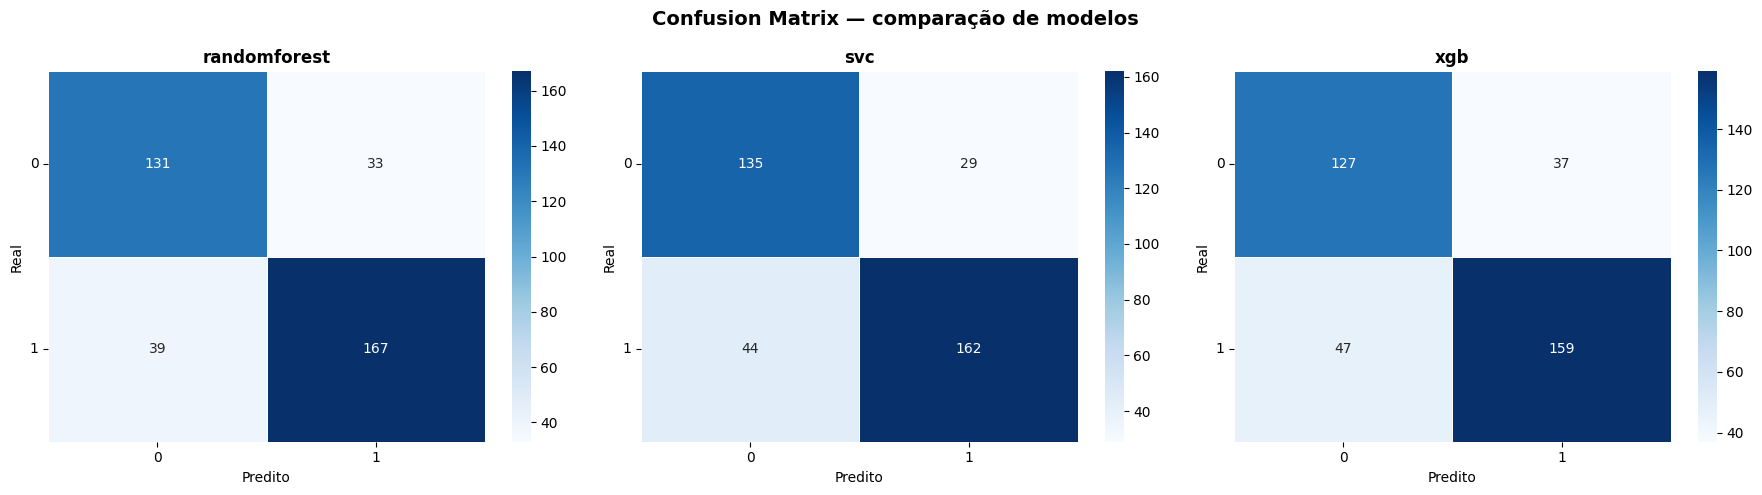


Figura salva em confusion_matrices.png


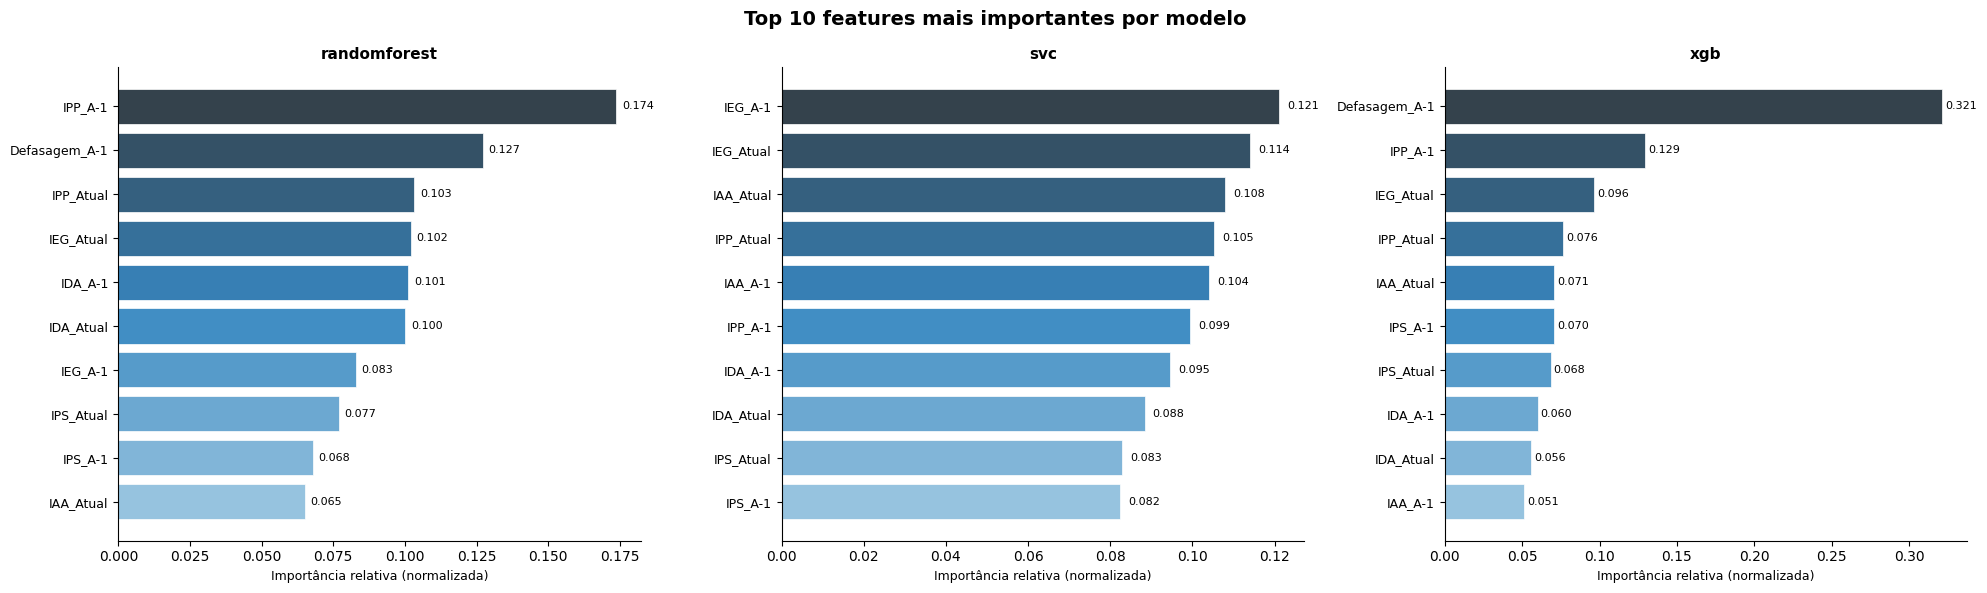

Figura salva em feature_importance.png


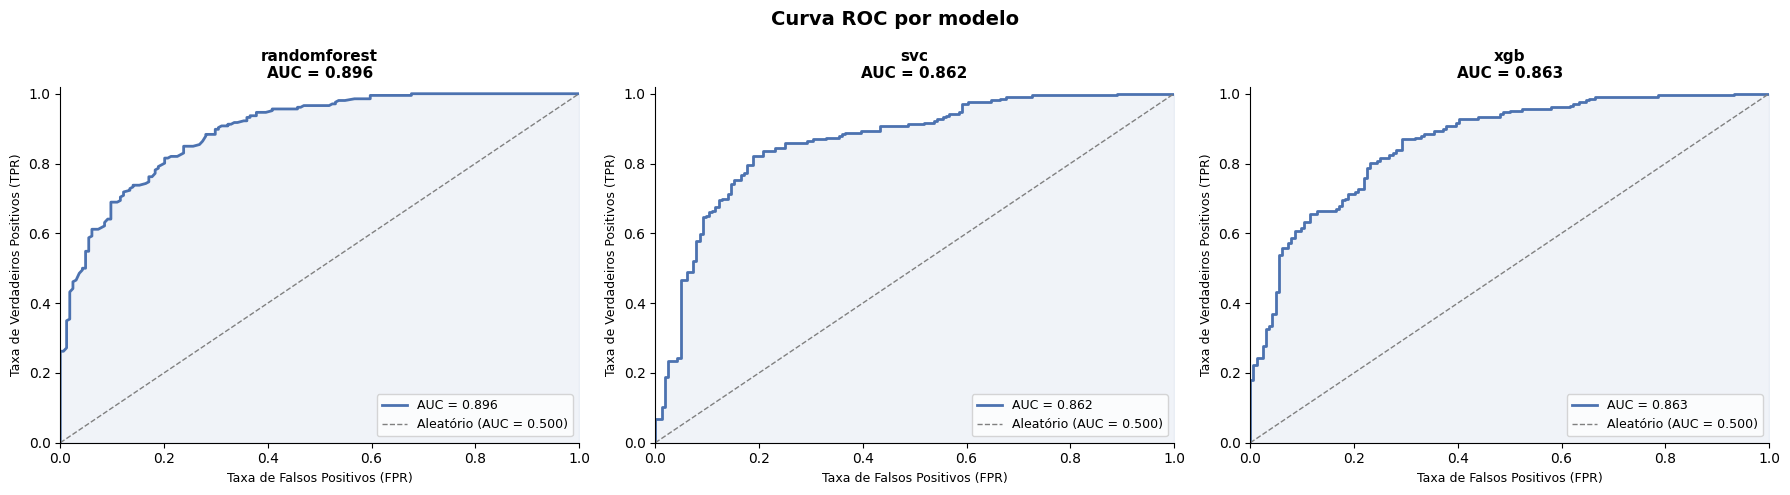

Figura salva em roc_auc.png


In [204]:
import matplotlib.pyplot as plt
import seaborn as sns
# Treina, avalia e plota para cada pipeline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrix — comparação de modelos", fontsize=14, fontweight="bold")

for ax, (nome, pipe) in zip(axes, modelos.items()):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Classification Report
    print(f"\n{'='*50}")
    print(f"Modelo: {nome}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(nome, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predito", fontsize=10)
    ax.set_ylabel("Real", fontsize=10)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigura salva em confusion_matrices.png")

feature_names = np.array(X.columns)

fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Top 10 features mais importantes por modelo", fontsize=14, fontweight="bold")

for ax, (nome, pipe) in zip(axes2, modelos.items()):
    clf = pipe.named_steps["clf"]

    # Extrai importâncias conforme o tipo de modelo
    if hasattr(clf, "feature_importances_"):
        # Random Forest
        importancias = clf.feature_importances_

    elif hasattr(clf, "coef_"):
        # Regressão Logística — usa o valor absoluto dos coeficientes
        importancias = np.abs(clf.coef_[0])

    else:
        # SVM com kernel RBF não expõe pesos diretamente;
        # usa a magnitude dos vetores de suporte como proxy
        importancias = np.abs(clf.support_vectors_).mean(axis=0)

    # Seleciona as 10 maiores
    indices = np.argsort(importancias)[::-1][:10]
    top_importancias = importancias[indices]
    top_features    = feature_names[indices]

    # Normaliza para facilitar comparação visual entre modelos
    top_importancias_norm = top_importancias / top_importancias.sum()

    cores = sns.color_palette("Blues_d", len(top_importancias_norm))
    barras = ax.barh(
        range(len(top_features)),
        top_importancias_norm[::-1],
        color=cores,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features[::-1], fontsize=9)
    ax.set_xlabel("Importância relativa (normalizada)", fontsize=9)
    ax.set_title(nome, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    # Anota o valor em cada barra
    for barra, val in zip(barras, top_importancias_norm[::-1]):
        ax.text(
            val + 0.002,
            barra.get_y() + barra.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em feature_importance.png")

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle("Curva ROC por modelo", fontsize=14, fontweight="bold")

for ax, (nome, pipe) in zip(axes3, modelos.items()):
    y_score = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
            lw=1, label="Aleatório (AUC = 0.500)")
    ax.fill_between(fpr, tpr, alpha=0.08, color="#4C72B0")

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=9)
    ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=9)
    ax.set_title(f"{nome}\nAUC = {roc_auc:.3f}", fontsize=11, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("roc_auc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em roc_auc.png")

In [214]:
randomforest.model.classes_

NameError: name 'randomforest' is not defined

### Exportação do Modelo

In [100]:
import joblib
modelo_randomforest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    criterion='entropy'
    )

joblib.dump(modelo_randomforest, 'random_forest_classifier.joblib')

['random_forest_classifier.joblib']